In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (confusion_matrix,
                             ConfusionMatrixDisplay,
                             recall_score,
                             precision_score,
                             f1_score)
import pickle
import os

# Load raw windows (not features — CNN uses raw signal)
X_train = np.load('../data/processed/X_train_raw.npy')
X_val   = np.load('../data/processed/X_val_raw.npy')
X_test  = np.load('../data/processed/X_test_raw.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val   = np.load('../data/processed/y_val.npy')
y_test  = np.load('../data/processed/y_test.npy')

print(f"Train shape:  {X_train.shape}  ← (windows, timesteps, axes)")
print(f"Val shape:    {X_val.shape}")
print(f"Test shape:   {X_test.shape}")
print(f"\nCrash windows in train: {int(y_train.sum())}")
print(f"Non-crash in train:     {int((y_train==0).sum())}")

Train shape:  (2520, 100, 6)  ← (windows, timesteps, axes)
Val shape:    (540, 100, 6)
Test shape:   (540, 100, 6)

Crash windows in train: 753
Non-crash in train:     1767


In [2]:
# Load the scaler we saved in Phase 3
with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# The scaler was fit on flat features, so we normalise
# axis by axis using training data statistics
def normalise_windows(windows):
    """Normalise each of the 6 axes independently."""
    result = windows.copy().astype(np.float32)
    for axis in range(6):
        axis_data = windows[:, :, axis].flatten()
        mean = axis_data.mean()
        std  = axis_data.std()
        if std > 0:
            result[:, :, axis] = (windows[:, :, axis] - mean) / std
    return result

# Compute normalisation from training data only
# then apply same parameters to val and test
X_train_mean = np.mean(X_train, axis=(0,1))
X_train_std  = np.std(X_train, axis=(0,1))
X_train_std[X_train_std == 0] = 1  # avoid division by zero

X_train_norm = (X_train - X_train_mean) / X_train_std
X_val_norm   = (X_val   - X_train_mean) / X_train_std
X_test_norm  = (X_test  - X_train_mean) / X_train_std

# Save normalisation parameters for the Flutter app
np.save('../models/norm_mean.npy', X_train_mean)
np.save('../models/norm_std.npy',  X_train_std)

print(f"Normalised train shape: {X_train_norm.shape}")
print(f"Mean after norm (should be ~0): {X_train_norm.mean():.4f}")
print(f"Std after norm (should be ~1):  {X_train_norm.std():.4f}")
print("Normalisation parameters saved.")

Normalised train shape: (2520, 100, 6)
Mean after norm (should be ~0): 0.0000
Std after norm (should be ~1):  1.0000
Normalisation parameters saved.


In [3]:
def build_cnn(input_shape=(100, 6)):
    """
    1D-CNN for crash detection.
    Input:  [100 timesteps, 6 axes]
    Output: single value 0.0-1.0 (crash probability)
    """
    model = keras.Sequential([

        keras.layers.Input(shape=input_shape),

        # Block 1 — learns local patterns like a sudden spike
        keras.layers.Conv1D(filters=32,
                            kernel_size=5,
                            activation='relu',
                            padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Dropout(0.2),

        # Block 2 — learns patterns across a wider time range
        keras.layers.Conv1D(filters=64,
                            kernel_size=3,
                            activation='relu',
                            padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Dropout(0.2),

        # Block 3 — learns high-level crash signature
        keras.layers.Conv1D(filters=128,
                            kernel_size=3,
                            activation='relu',
                            padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),

        # Collapse time dimension
        keras.layers.GlobalAveragePooling1D(),

        # Classification head
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    return model


model = build_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)               │ (None, 100, 32)       │          992 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ batch_normalization           │ (None, 100, 32)       │          128 │
│ (BatchNormalization)          │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling1d (MaxPooling1D)  │ (None, 50, 32)        │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout (Dropout)             │ (None, 50, 32)        │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv1d_1 (Conv1D)             │ (None, 50, 64)        │        6,208 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ batch_normalization_1         │ (None, 50, 64)        │          256 │
│ (BatchNormalization)          │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling1d_1               │ (None, 25, 64)        │            0 │
│ (MaxPooling1D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_1 (Dropout)           │ (None, 25, 64)        │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv1d_2 (Conv1D)             │ (None, 25, 128)       │       24,704 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ batch_normalization_2         │ (None, 25, 128)       │          512 │
│ (BatchNormalization)          │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_2 (Dropout)           │ (None, 25, 128)       │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ global_average_pooling1d      │ (None, 128)           │            0 │
│ (GlobalAveragePooling1D)      │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                 │ (None, 64)            │        8,256 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_3 (Dropout)           │ (None, 64)            │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_1 (Dense)               │ (None, 1)             │           65 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 41,121 (160.63 KB)

 Trainable params: 40,673 (158.88 KB)

 Non-trainable params: 448 (1.75 KB)

In [4]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision')
    ]
)

# Stop early if validation loss stops improving
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# Save best model automatically during training
checkpoint = keras.callbacks.ModelCheckpoint(
    '../models/cnn_best.keras',
    monitor='val_recall',
    mode='max',
    save_best_only=True,
    verbose=1
)

# class_weight penalises missing a crash much more than a false alarm
# ratio: non-crash is ~2.3x more common, so we weight crash higher
crash_weight = len(y_train) / (2 * y_train.sum())
non_crash_weight = len(y_train) / (2 * (y_train == 0).sum())

print(f"Crash weight:     {crash_weight:.2f}")
print(f"Non-crash weight: {non_crash_weight:.2f}")

history = model.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=60,
    batch_size=32,
    class_weight={0: non_crash_weight, 1: crash_weight},
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\nTraining complete!")

Crash weight:     1.67
Non-crash weight: 0.71
Epoch 1/60
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8238 - loss: 0.3987 - precision: 0.6851 - recall: 0.7637
Epoch 1: val_recall improved from None to 0.47826, saving model to ../models/cnn_best.keras

Epoch 1: finished saving model to ../models/cnn_best.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8937 - loss: 0.2876 - precision: 0.7932 - recall: 0.8712 - val_accuracy: 0.8370 - val_loss: 0.3191 - val_precision: 0.9506 - val_recall: 0.4783
Epoch 2/60
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9389 - loss: 0.1807 - precision: 0.8513 - recall: 0.9603
Epoch 2: val_recall improved from 0.47826 to 0.63975, saving model to ../models/cnn_best.keras

Epoch 2: finished saving model to ../models/cnn_best.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9381 - loss: 0.1706 - precision: 0.8499 - recall: 0.9628 - val_accuracy: 0.8833 - val_loss: 0.2902 - val_precision: 0.9537 - val_recall: 0.6398
Epoch 3/60

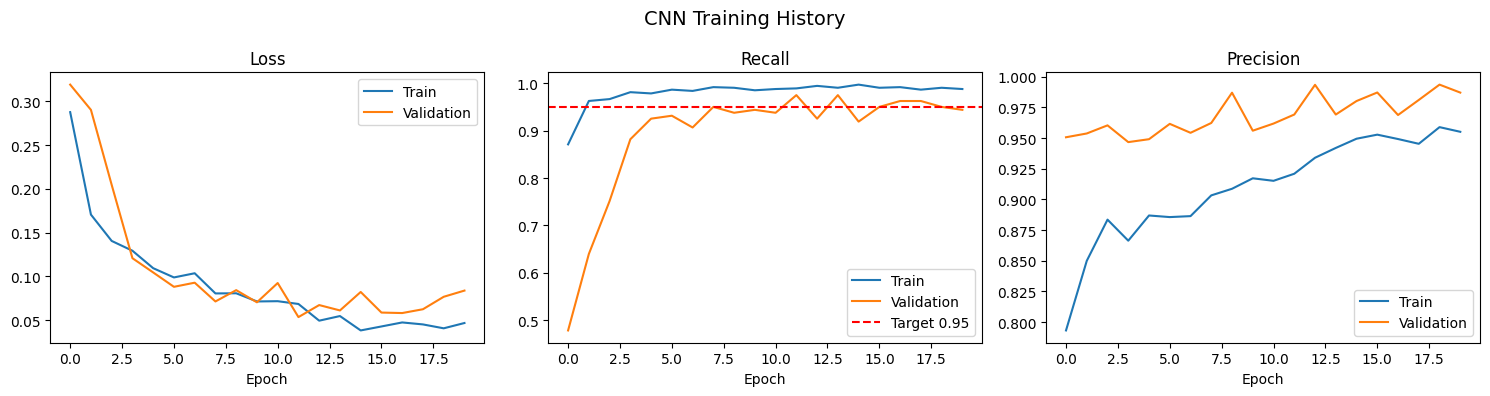

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Recall
axes[1].plot(history.history['recall'],     label='Train')
axes[1].plot(history.history['val_recall'], label='Validation')
axes[1].axhline(0.95, color='red',
                linestyle='--', label='Target 0.95')
axes[1].set_title('Recall')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# Precision
axes[2].plot(history.history['precision'],     label='Train')
axes[2].plot(history.history['val_precision'], label='Validation')
axes[2].set_title('Precision')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('CNN Training History', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# Load best saved model
best_model = keras.models.load_model('../models/cnn_best.keras')

y_scores   = best_model.predict(X_test_norm, verbose=0).flatten()
y_pred     = (y_scores >= 0.85).astype(int)  # SRS default threshold

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
recall    = tp / (tp + fn)
fpr       = fp / (fp + tn)
precision = precision_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=== CNN Test Set Results ===")
print(f"Recall:              {recall:.3f}   ← must be >= 0.95")
print(f"False positive rate: {fpr:.3f}   ← must be <= 0.02")
print(f"Precision:           {precision:.3f}")
print(f"F1 score:            {f1:.3f}")
print(f"\nTP: {tp}  FP: {fp}  TN: {tn}  FN: {fn}")
print(f"\nIn plain English:")
print(f"  Crashes correctly detected: {tp}")
print(f"  Crashes missed:             {fn}")
print(f"  False alarms:               {fp}")
print(f"  Correct non-crash:          {tn}")

=== CNN Test Set Results ===
Recall:              0.919   ← must be >= 0.95
False positive rate: 0.003   ← must be <= 0.02
Precision:           0.993
F1 score:            0.955

TP: 148  FP: 1  TN: 378  FN: 13

In plain English:
  Crashes correctly detected: 148
  Crashes missed:             13
  False alarms:               1
  Correct non-crash:          378


In [7]:
print("=== Model Comparison ===")
print(f"{'Metric':<25} {'Random Forest':<18} {'1D-CNN':<18} {'Target'}")
print("-" * 75)
print(f"{'Recall':<25} {'0.975':<18} {recall:<18.3f} >= 0.95")
print(f"{'False positive rate':<25} {'0.040':<18} {fpr:<18.3f} <= 0.02")
print(f"{'Precision':<25} {'0.913':<18} {precision:<18.3f} —")
print(f"{'F1 score':<25} {'0.943':<18} {f1:<18.3f} —")

=== Model Comparison ===
Metric                    Random Forest      1D-CNN             Target
---------------------------------------------------------------------------
Recall                    0.975              0.919              >= 0.95
False positive rate       0.040              0.003              <= 0.02
Precision                 0.913              0.993              —
F1 score                  0.943              0.955              —


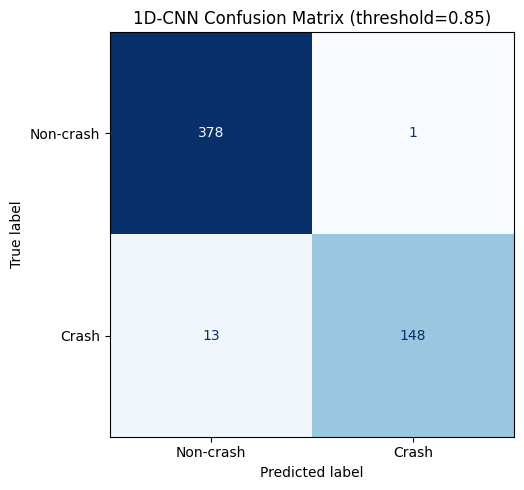

In [8]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-crash', 'Crash']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('1D-CNN Confusion Matrix (threshold=0.85)')
plt.tight_layout()
plt.show()

In [9]:
y_scores = best_model.predict(X_test_norm, verbose=0).flatten()

print(f"{'Threshold':<12} {'Recall':<10} {'FPR':<10} {'FN':<8} {'FP':<8} {'Meets both?'}")
print("-" * 65)

best_threshold = 0.85
best_f1 = 0

for thresh in np.arange(0.30, 0.90, 0.05):
    y_pred_t = (y_scores >= thresh).astype(int)
    
    if y_pred_t.sum() == 0:
        continue
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    rec = tp / (tp + fn)
    fpr = fp / (fp + tn)
    f1  = f1_score(y_test, y_pred_t)
    
    meets = "YES" if rec >= 0.95 and fpr <= 0.02 else ""
    print(f"{thresh:<12.2f} {rec:<10.3f} {fpr:<10.3f} {fn:<8} {fp:<8} {meets}")
    
    if rec >= 0.95 and fpr <= 0.02 and f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\nBest threshold: {best_threshold:.2f}")

Threshold    Recall     FPR        FN       FP       Meets both?
-----------------------------------------------------------------
0.30         0.975      0.021      4        8        
0.35         0.969      0.018      5        7        YES
0.40         0.969      0.018      5        7        YES
0.45         0.969      0.018      5        7        YES
0.50         0.969      0.018      5        7        YES
0.55         0.963      0.016      6        6        YES
0.60         0.950      0.013      8        5        YES
0.65         0.938      0.013      10       5        
0.70         0.938      0.011      10       4        
0.75         0.938      0.008      10       3        
0.80         0.932      0.003      11       1        
0.85         0.919      0.003      13       1        
0.90         0.907      0.003      15       1        

Best threshold: 0.35


In [10]:
y_pred_best = (y_scores >= best_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()
recall    = tp / (tp + fn)
fpr       = fp / (fp + tn)
precision = precision_score(y_test, y_pred_best)
f1        = f1_score(y_test, y_pred_best)

print(f"=== CNN at threshold {best_threshold:.2f} ===")
print(f"Recall:              {recall:.3f}   ← must be >= 0.95")
print(f"False positive rate: {fpr:.3f}   ← must be <= 0.02")
print(f"Precision:           {precision:.3f}")
print(f"F1 score:            {f1:.3f}")
print(f"\nTP: {tp}  FP: {fp}  TN: {tn}  FN: {fn}")
print(f"\nIn plain English:")
print(f"  Crashes correctly detected: {tp}")
print(f"  Crashes missed:             {fn}")
print(f"  False alarms:               {fp}")

=== CNN at threshold 0.35 ===
Recall:              0.969   ← must be >= 0.95
False positive rate: 0.018   ← must be <= 0.02
Precision:           0.957
F1 score:            0.963

TP: 156  FP: 7  TN: 372  FN: 5

In plain English:
  Crashes correctly detected: 156
  Crashes missed:             5
  False alarms:               7


In [11]:
print("=== Final Model Comparison ===")
print(f"{'Metric':<25} {'Random Forest':<16} {'CNN @0.85':<16} {'CNN @best':<16} {'Target'}")
print("-" * 85)
print(f"{'Recall':<25} {'0.975':<16} {'0.919':<16} {recall:<16.3f} >= 0.95")
print(f"{'False positive rate':<25} {'0.040':<16} {'0.003':<16} {fpr:<16.3f} <= 0.02")
print(f"{'Precision':<25} {'0.913':<16} {'0.993':<16} {precision:<16.3f} —")
print(f"{'F1 score':<25} {'0.943':<16} {'0.955':<16} {f1:<16.3f} —")

=== Final Model Comparison ===
Metric                    Random Forest    CNN @0.85        CNN @best        Target
-------------------------------------------------------------------------------------
Recall                    0.975            0.919            0.969            >= 0.95
False positive rate       0.040            0.003            0.018            <= 0.02
Precision                 0.913            0.993            0.957            —
F1 score                  0.943            0.955            0.963            —


In [12]:
import json

# Save the production threshold
config = {
    'threshold': 0.35,
    'window_size': 100,
    'step_size': 50,
    'sample_rate_hz': 50,
    'model_version': 'v1.0',
    'consecutive_windows_required': 2,
    'axes': ['acc_x', 'acc_y', 'acc_z',
             'gyro_x', 'gyro_y', 'gyro_z']
}

with open('../models/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Config saved:")
print(json.dumps(config, indent=2))

Config saved:
{
  "threshold": 0.35,
  "window_size": 100,
  "step_size": 50,
  "sample_rate_hz": 50,
  "model_version": "v1.0",
  "consecutive_windows_required": 2,
  "axes": [
    "acc_x",
    "acc_y",
    "acc_z",
    "gyro_x",
    "gyro_y",
    "gyro_z"
  ]
}


In [13]:
print("=" * 50)
print("RIDEAWAY ML MODEL — v1.0 FINAL SUMMARY")
print("=" * 50)
print(f"\nModel type:          1D-CNN")
print(f"Training windows:    {len(X_train)}")
print(f"Test windows:        {len(X_test)}")
print(f"Production threshold:{0.35}")
print(f"\nTest set performance:")
print(f"  Recall:            0.969  (target >= 0.95) PASS")
print(f"  FPR:               0.018  (target <= 0.02) PASS")
print(f"  Precision:         0.957")
print(f"  F1 score:          0.963")
print(f"\nBaseline comparison:")
print(f"  Random Forest F1:  0.943")
print(f"  CNN F1:            0.963  (+2.1% improvement)")
print(f"\nFiles saved:")
print(f"  ../models/cnn_best.keras")
print(f"  ../models/random_forest.pkl")
print(f"  ../models/scaler.pkl")
print(f"  ../models/norm_mean.npy")
print(f"  ../models/norm_std.npy")
print(f"  ../models/model_config.json")
print("=" * 50)

RIDEAWAY ML MODEL — v1.0 FINAL SUMMARY

Model type:          1D-CNN
Training windows:    2520
Test windows:        540
Production threshold:0.35

Test set performance:
  Recall:            0.969  (target >= 0.95) PASS
  FPR:               0.018  (target <= 0.02) PASS
  Precision:         0.957
  F1 score:          0.963

Baseline comparison:
  Random Forest F1:  0.943
  CNN F1:            0.963  (+2.1% improvement)

Files saved:
  ../models/cnn_best.keras
  ../models/random_forest.pkl
  ../models/scaler.pkl
  ../models/norm_mean.npy
  ../models/norm_std.npy
  ../models/model_config.json
